# Entendimento dos Dados (EDA)

# Importando bibliotecas

- Todas as bibliotecas estão disponíveis para download em projeto-final-rh-analytics/techcorp_attrition/requirements.txt
- O ambiente virtual foi instalado com a versão mais recente do python - 3.14.5

### Passos para criação do Kernel VSCode
Rode os seguintes comandos - supondo que já realizou a criação do ambiente virtual
- Ativar o ambiente virtual (se ainda não estiver ativo): .venv\Scripts\activate
- Instalar o ipykernel no ambiente: pip install ipykernel
- Registrar o kernel no Jupyter: python -m ipykernel install --user --name=XXnome-venvXX --display-name "Python xx.xx.xx (meu-projeto)"
- Verificar se o kernel foi registrado: jupyter kernelspec list
- Remover o kernel quando não precisar mais: jupyter kernelspec remove meu-projeto


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")

# 1 - Carregamento dos dados

In [2]:
# Carregando o dataset
df = pd.read_csv('../../fonte_dados/ibm_hr_analytics_sintetico_final.csv')

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dimensões do dataset: 1000000 linhas x 35 colunas


# 2 - Análise Exploratória Inicial

In [3]:
# Primeira visualização
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,No,Travel_Rarely,590,Research & Development,19,1,Other,1,1,4,Female,73,3,3,Research Director,3,Divorced,12378,24652,1,Y,Yes,18,3,1,80,3,33,2,2,29,11,11,1
1,46,No,Travel_Rarely,1441,Human Resources,5,1,Life Sciences,1,2,4,Male,88,4,1,Laboratory Technician,3,Married,9987,15406,2,Y,Yes,12,3,1,80,2,37,3,3,37,6,5,16
2,32,Yes,Travel_Frequently,748,Research & Development,2,3,Medical,1,3,4,Male,89,4,2,Sales Representative,2,Divorced,1276,16073,1,Y,No,15,3,2,80,0,26,1,1,16,3,15,12
3,60,No,Travel_Rarely,1311,Human Resources,3,4,Life Sciences,1,4,2,Female,41,1,4,Research Scientist,2,Single,1807,23260,3,Y,No,17,3,4,80,2,29,3,2,29,17,6,9
4,25,No,Non-Travel,144,Sales,10,4,Life Sciences,1,5,4,Male,66,1,2,Manager,3,Married,14635,2614,1,Y,No,12,3,2,80,1,22,6,4,6,2,6,14


#### Describe do dataframe

**Describe para variáveis numéricas**

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000000.0,41.000062,13.564537,18.0,29.00,41.0,53.00,64.0
DailyRate,1000000.0,799.932980,404.415724,100.0,450.00,800.0,1150.00,1499.0
DistanceFromHome,1000000.0,15.021016,8.365798,1.0,8.00,15.0,22.00,29.0
Education,1000000.0,2.500602,1.118390,1.0,1.00,3.0,4.00,4.0
EmployeeCount,1000000.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1000000.0,500000.500000,288675.278932,1.0,250000.75,500000.5,750000.25,1000000.0
EnvironmentSatisfaction,1000000.0,2.498100,1.118145,1.0,1.00,2.0,3.00,4.0
HourlyRate,1000000.0,64.486837,20.202957,30.0,47.00,64.0,82.00,99.0
JobInvolvement,1000000.0,2.499435,1.117884,1.0,1.00,2.0,3.00,4.0
JobLevel,1000000.0,2.999672,1.413922,1.0,2.00,3.0,4.00,5.0


**Describe para variáveis categóricas**

In [5]:
df.describe(include='object').T

,count,unique,top,freq
Attrition,1000000,2,No,839867
BusinessTravel,1000000,3,Travel_Frequently,333665
Department,1000000,3,Sales,333749
EducationField,1000000,6,Other,167152
Gender,1000000,2,Female,500211
JobRole,1000000,9,Human Resources,111726
MaritalStatus,1000000,3,Married,333467
Over18,1000000,1,Y,1000000
OverTime,1000000,2,No,719728


#### Validações adicionais

Essa análise garante verificar:

- tipagem dos dados
- quantidade de valores únicos
- valores ausentes
- porcentagem de valores ausentes
- quantidade de duplicatas

In [6]:
def dataframe_overview(data):
    overview = pd.DataFrame({
        "data_type": data.dtypes.astype(str),
        "qtd_value_unique": data.nunique(),
        "missing": data.isna().sum(),
        "missing_pct": data.isna().mean() * 100,
        "duplicated_values": [data[col].duplicated().sum() for col in data.columns]
    })
    return overview.sort_values(["missing_pct", "qtd_value_unique"], ascending=[False, True])

overview = dataframe_overview(df)
overview

,data_type,qtd_value_unique,missing,missing_pct,duplicated_values
EmployeeCount,int64,1,0,0.0,999999
Over18,str,1,0,0.0,999999
StandardHours,int64,1,0,0.0,999999
Attrition,str,2,0,0.0,999998
Gender,str,2,0,0.0,999998
OverTime,str,2,0,0.0,999998
PerformanceRating,int64,2,0,0.0,999998
BusinessTravel,str,3,0,0.0,999997
Department,str,3,0,0.0,999997
MaritalStatus,str,3,0,0.0,999997


##### **Variáveis desnecessárias**:

Variáveis que são irrelevantes para predição do modelo:
- EmployeeCount: valor 1 para todos, não agrega informação
- StandardHours: valor 80 para todos, não agrega informação
- Over18: valor "Y" para todos, não agrega informação
- EmployeeNumber: Identificador único, não é uma feature. A presença de identificadores únicos pode levar ao data leakage, onde o modelo memoriza resultados do conjunto de treino que não se repetirão no conjunto de validação ou produção, mascarando a real eficácia do algoritmo.

In [7]:
# Retirando colunas desnecessárias
df_raw = df.copy()
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])
 
print(df.shape)

(1000000, 31)


#### Criando variável binária para Attrition

In [8]:
df_eda = df.copy()
df_eda["AttritionFlag"] = (df_eda["Attrition"] == "Yes").astype(int)

#### Peso da target

In [12]:
# Quantidade de registros agrupando por Yes e No
print(df_eda['AttritionFlag'].value_counts())
print()
# Porcentagem dos registros agrupando por Yes e No
print(df_eda['AttritionFlag'].value_counts(normalize=True))

AttritionFlag
0    839867
1    160133
Name: count, dtype: int64

AttritionFlag
0    0.839867
1    0.160133
Name: proportion, dtype: float64


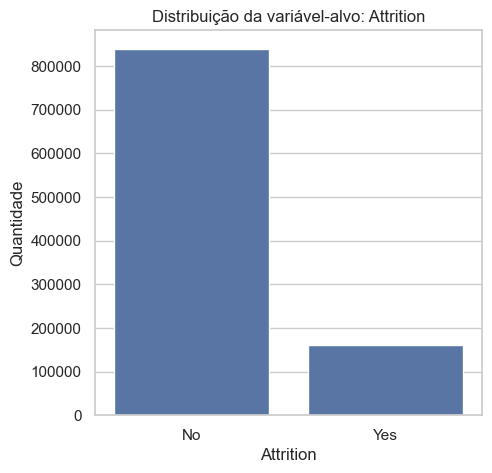

In [14]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df_eda, x="Attrition")
plt.title("Distribuição da variável-alvo: Attrition")
plt.xlabel("Attrition")
plt.ylabel("Quantidade")
plt.savefig('../reports/distribuicao_variavel_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

**A target está desbalanceada**

Definimos a coluna Attrition como target, pois o modelo indica se o colaborador teve um desligamento ou não. Como observado nos dados e gráficos anteriores, há um desbalanceamento considerável entre as classes. Conforme observado, o conjunto de dados apresenta um desbalanceamento significativo, com cerca de 84% dos funcionários mantendo o vínculo e apenas 16% registrando a saída.

|Attrition | % |
|--|--|
|No | 83,98% |
|Yes | 16,01% |

Ao desenvolver o modelo, este desbalanceamento exige atenção redobrada. Caso não seja tratado, o algoritmo terá dificuldade em prever a classe minoritária ('Yes'). Esse ponto é crucial e alinha-se ao que foi levantado na etapa de Business Understanding: para a empresa, o prejuízo é maior quando o modelo prevê que o funcionário permanecerá, mas ele acaba saindo (falso negativo). 

**Objetivo**

Nosso objetivo é otimizar o modelo para minimizar esses erros, aumentando a assertividade na identificação de colaboradores em risco de desligamento, tendo como foco os verdadeiros positivos.


# 3 - Distribuição das Variáveis Numéricas

## Por que analisar a distribuição das variáveis numéricas?


Antes de usar qualquer variável no modelo, você precisa **conhecê-la**.
A distribuição te responde 4 perguntas fundamentais:

---

### 1. A variável tem outliers?

```
Exemplo: MonthlyIncome
Maioria dos funcionários: R$ 3.000 - R$ 15.000
Um registro:             R$ 250.000  ← outlier

Impacto no modelo: a Regressão Logística é sensível a outliers
→ esse valor extremo pode distorcer os coeficientes do modelo
```

---

### 2. Qual é o formato da distribuição?

```
Normal (simétrica)     →  a maioria no centro, poucos nas extremidades
Assimétrica à direita  →  maioria com valores baixos, poucos com valores altos
Bimodal                →  dois picos → pode indicar dois grupos distintos
```

> Isso importa porque o `StandardScaler` assume distribuição aproximadamente normal.
> Se a distribuição for muito assimétrica, pode ser necessário aplicar uma transformação antes.

---

### 3. A variável realmente é numérica contínua ou é ordinal disfarçada?

```
JobSatisfaction:  valores 1, 2, 3, 4
→ parece número mas significa: Baixo, Médio, Alto, Muito Alto
→ tratar como número puro pode fazer o modelo entender que
  a diferença entre 1 e 2 é igual à diferença entre 3 e 4
→ precisa de tratamento especial no pré-processamento
```

---

### 4. As distribuições são diferentes entre quem saiu e quem ficou?

```
Exemplo: Age
  Ficou:  média 38 anos  ──────█████──────
  Saiu:   média 29 anos  ────█████────────
                                  ↑
                         diferença visível!
→ Age provavelmente é uma boa feature para o modelo
```

> Se as distribuições forem **iguais** entre quem saiu e quem ficou,
> a variável provavelmente **não vai ajudar** o modelo a distinguir os dois grupos.

---

### Resumindo — o que a análise de distribuição nos entrega

| O que analisamos | Decisão que isso gera |
|---|---|
| Outliers | Tratar ou não na Etapa 3 |
| Formato da distribuição | Aplicar transformação ou não |
| Ordinal vs contínua | Definir encoding correto |
| Diferença entre grupos | Selecionar ou descartar features |

---

> Não estamos fazendo gráficos bonitos por fazer —
> cada visualização vai **informar uma decisão concreta**
> no pré-processamento e na seleção de features.

##   

In [15]:
feature_cols = [c for c in df_eda.columns if c not in ["Attrition", "AttritionFlag"]]

num_cols = df_eda[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = df_eda[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Categóricas: {cat_cols}")
print(f"Numéricas: {num_cols}")

Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [16]:
print(f'Total de variáveis categóricas: {len(cat_cols)}')
print(f'Total de variáveis numéricas: {len(num_cols)}')

Total de variáveis categóricas: 7
Total de variáveis numéricas: 23


## Variáveis Ordinais Disfarçadas de Número

Dentre as 23 variáveis numéricas identificadas, as seguintes são **escalas ordinais**
— possuem ordem, mas a distância entre os valores não é necessariamente igual:

| Variável | Valores | O que significa |
|---|---|---|
| `Education` | 1-5 | 1=Abaixo da faculdade … 5=Doutorado |
| `EnvironmentSatisfaction` | 1-4 | 1=Baixo … 4=Muito Alto |
| `JobInvolvement` | 1-4 | 1=Baixo … 4=Muito Alto |
| `JobLevel` | 1-5 | Nível hierárquico |
| `JobSatisfaction` | 1-4 | 1=Baixo … 4=Muito Alto |
| `PerformanceRating` | 1-4 | 1=Baixo … 4=Excelente |
| `RelationshipSatisfaction` | 1-4 | 1=Baixo … 4=Muito Alto |
| `StockOptionLevel` | 0-3 | Nível de opções de ações |
| `WorkLifeBalance` | 1-4 | 1=Ruim … 4=Excelente |

In [17]:
# Numéricas contínuas reais
num_continuas = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                 'YearsWithCurrManager']

# Escalas ordinais disfarçadas de número
num_ordinais = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

print(f"Contínuas: {len(num_continuas)}")
print(f"Ordinais:  {len(num_ordinais)}")

Contínuas: 14
Ordinais:  9


Realizando uma amostragem estratificada com as mesmas proporções da coluna 'Attrition'. Uma boa prática para que a geração das visualizaações não fique pesada

In [21]:
# Solução compatível com Pandas 2.0+
df_sample = (
    df_eda.groupby('Attrition', group_keys=False)
    .apply(lambda x: x.sample(frac=0.05, random_state=42), include_groups=False)
    .reset_index(drop=False)  # mantém o índice original que contém o Attrition
)

# Renomear se necessário
df_sample = df_eda.loc[
    df_eda.groupby('Attrition', group_keys=False)
    .apply(lambda x: x.sample(frac=0.05, random_state=42), include_groups=False)
    .index
]

print(f"Tamanho da amostra: {df_sample.shape[0]}")
print(f"\nProporção original:")
print(df_eda['Attrition'].value_counts(normalize=True))
print(f"\nProporção na amostra:")
print(df_sample['Attrition'].value_counts(normalize=True))

Tamanho da amostra: 50000

Proporção original:
Attrition
No     0.839867
Yes    0.160133
Name: proportion, dtype: float64

Proporção na amostra:
Attrition
No     0.83986
Yes    0.16014
Name: proportion, dtype: float64


Análise de attrition por variáveis contínuas importantes

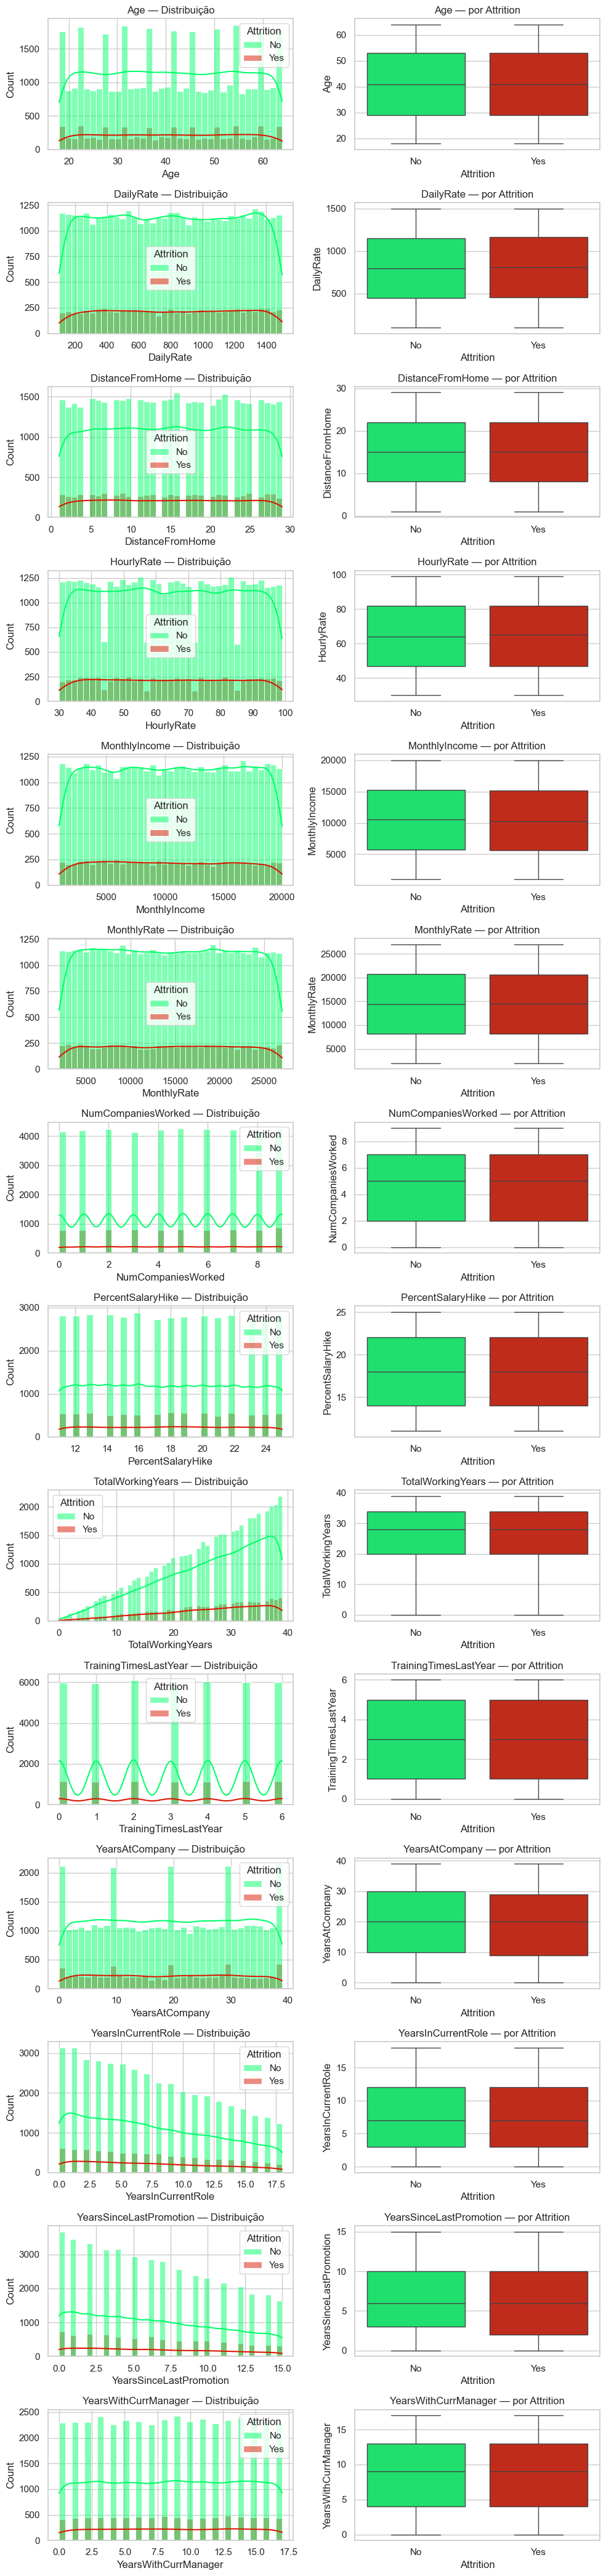

In [ ]:
fig, axes = plt.subplots(len(num_continuas), 2, figsize=(10, len(num_continuas) * 3))

for i, col in enumerate(num_continuas):
    # Histograma
    sns.histplot(data=df_sample, x=col, hue='Attrition', kde=True,
                 ax=axes[i, 0], palette={'Yes': "#da1600", 'No': "#00ff6a"})
    axes[i, 0].set_title(f'{col} — Distribuição')

    # Boxplot
    sns.boxplot(data=df_sample, x='Attrition', y=col,
                ax=axes[i, 1], palette={'Yes': "#db1600", 'No': "#00ff6a"})
    axes[i, 1].set_title(f'{col} — por Attrition')

plt.tight_layout()
plt.savefig('../reports/distribuicao_variaveis_continuas.png', dpi=150, bbox_inches='tight')
plt.show()

Análise de attrition por variáveis categóricas importantes


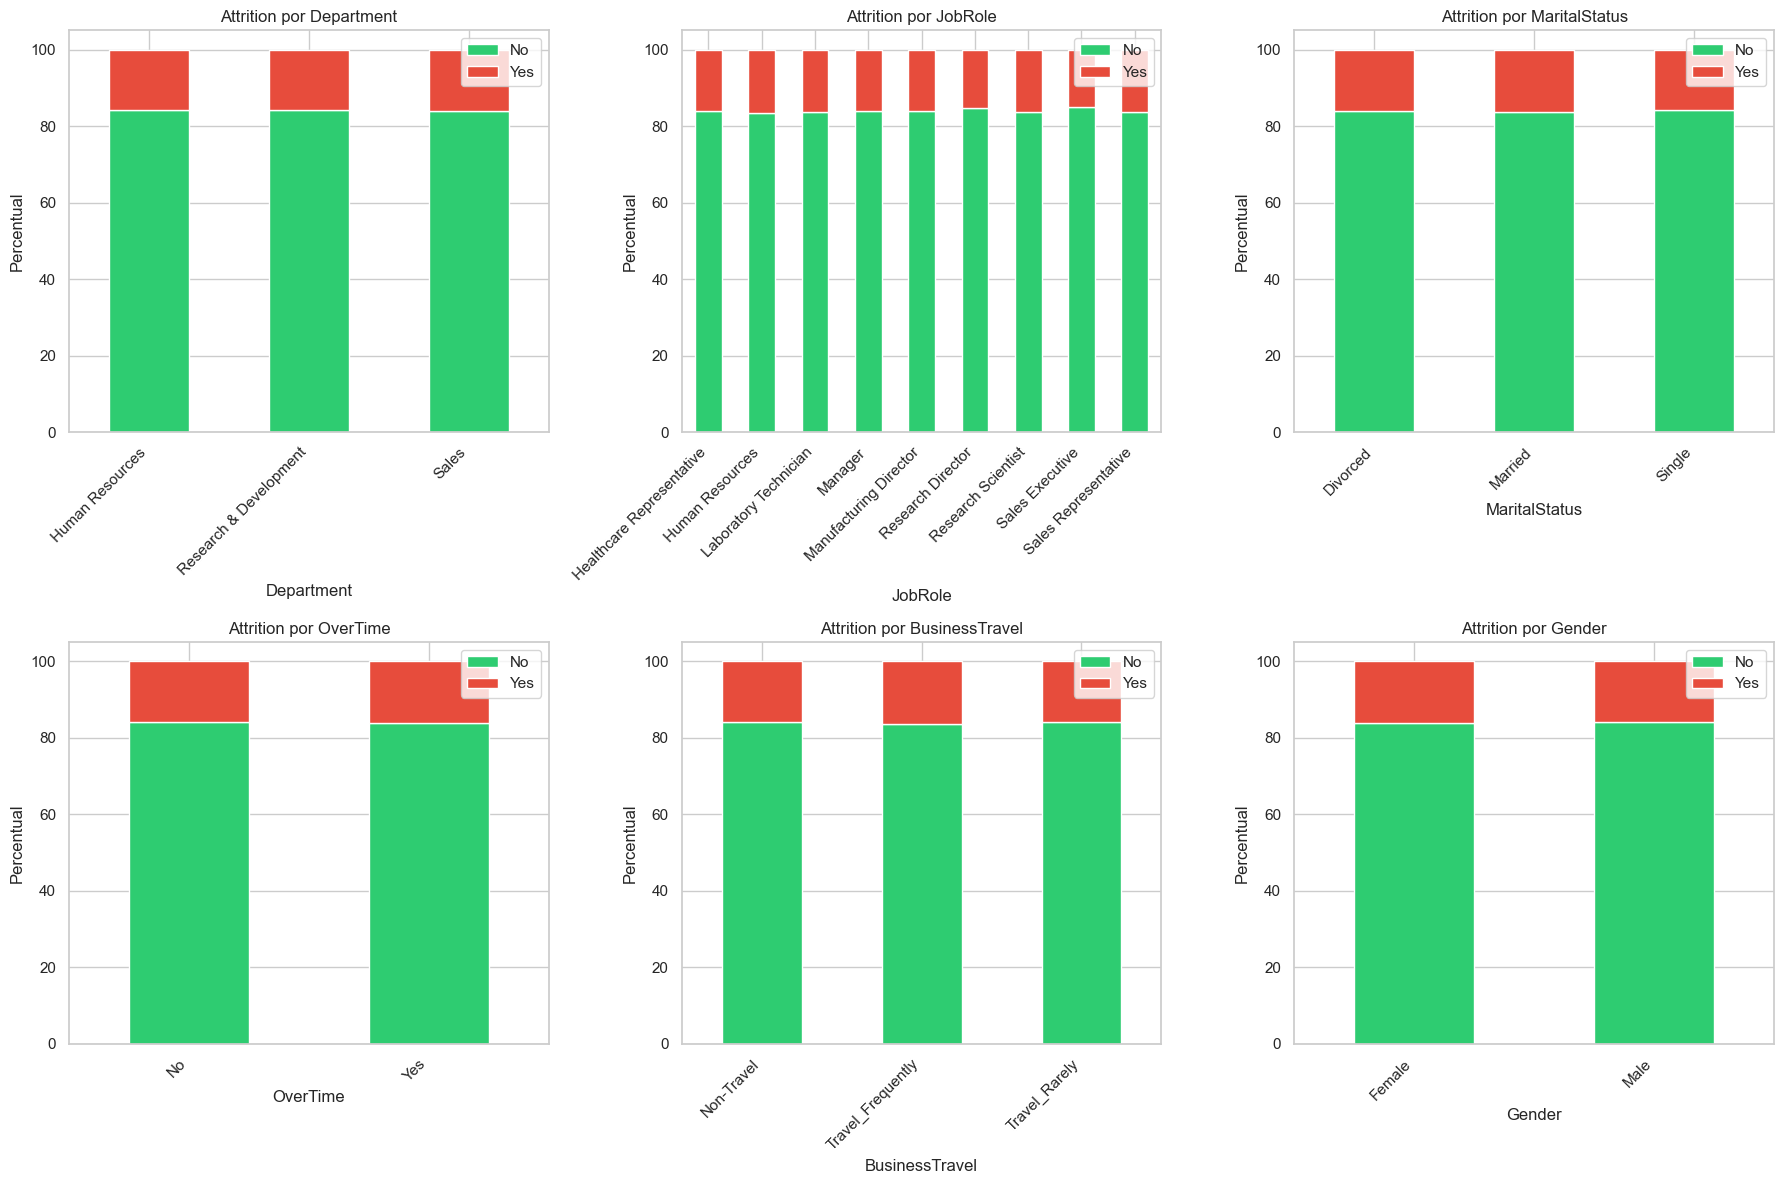

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

important_cats = ['Department', 'JobRole', 'MaritalStatus', 'OverTime', 'BusinessTravel', 'Gender']

for idx, col in enumerate(important_cats):
    crosstab = pd.crosstab(df_sample[col], df['Attrition'])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    crosstab_pct.plot(kind='bar', ax=axes[idx], stacked=True, color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'Attrition por {col}')
    axes[idx].set_ylabel('Percentual')
    axes[idx].legend(['No', 'Yes'], loc='upper right')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Antes de iniciar as interpretações dos gráficos, separar a coluna target do dataset
# TODO: Corrigir problem de push para o csv: File data/raw/ibm_hr_analytics_sintetico.csv is 168.57 MB; this exceeds GitHub's file size limit of 100.00 MB 